# Check whether the model is working

**NOTES:**
- The model needs finetuning before being evaluated.
- Currently only numerical features can be used


In [1]:
import sys
sys.path.append("../")
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from explainerpfn.base import ExplainerPFN
from explainerpfn.temp import (
    get_data,
    get_shap_values,
    train_random_forest,
    preprocess_data,
    analyze_correlation_results,
    plot_explanations,
)

# just a simple toy dataset (all continuous features)
df, df_train_rf, df_train, df_test = get_data("SPAMBASE")

cols_to_drop = df.columns[4:-1]
df = df.drop(columns=cols_to_drop)
df_train_rf = df_train_rf.drop(columns=cols_to_drop)
df_train = df_train.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)

(X_train_rf, y_train_rf), (X_train, y_train), (X_test, y_test) = preprocess_data(
    df_train_rf, df_train, df_test
)

clf, y_train, y_test = train_random_forest(X_train_rf, y_train_rf, X_train, X_test)

all_shap_values = []
for X, y in tqdm(
    list(zip([X_train, X_test], [y_train, y_test])),
    desc="Calculating SHAP values"
):
    X_shap = get_shap_values(X, clf, check_additivity=False, masker=X_train)
    df_shap = pd.DataFrame(X_shap.astype(float), columns=X.columns)
    df_shap["target"] = y
    all_shap_values.append((X_shap, df_shap))
    
(X_train_shap, df_shap_train), (X_test_shap, df_shap_test) = all_shap_values


Datasets:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating SHAP values:   0%|          | 0/2 [00:00<?, ?it/s]

100%|===================| 7183/7202 [03:21<00:00]        

# (Test) Train model on this dataset as well

In [2]:
import torch.optim as optim
import numpy as np
from tqdm.auto import tqdm

# Create a new ExplainerPFN for the feature we want to finetune
xai = ExplainerPFN(fit_mode="low_memory", model_path="../../test_explainerpfn_model.ckp", random_state=42)
xai.fit(X_train, y_train)

# Setup optimizer - using Adam with a relatively small learning rate
# NOTE: Probably use lr=1e-5
optimizer = optim.Adam(xai.model_.parameters(), lr=1e-4)

# Training parameters
num_epochs = 100
batch_size = len(X_train)
batch_size = batch_size if len(X_train) > batch_size else len(X_train)

# Training loop
losses = []
for epoch in tqdm(range(num_epochs), desc="Finetuning epochs"):
    # Shuffle indices for each epoch
    indices = np.random.permutation(len(X_train))
    epoch_losses = []
    
    # Batch training
    for start_idx in range(0, len(X_train), batch_size):
        batch_indices = indices[start_idx:start_idx + batch_size]
        
        # Get batch data
        X_batch = X_train.values[batch_indices]
        y_batch = y_train[batch_indices]
        shap_batch = X_train_shap[batch_indices]
        
        loss = xai.finetune(optimizer, X_batch, y_batch, shap_batch)
        
        # Record loss
        epoch_losses.append(loss)
    
    # Average loss for the epoch
    avg_loss = sum(epoch_losses) / len(epoch_losses)
    losses.append(avg_loss)
    
    # if epoch % 5 == 0:
    #     print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")
    print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")

    # Save the finetuned model
    xai.save_foundation_model("../../test_explainerpfn_model.ckp")

# Plot the training loss curve
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


Finetuning epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0, Loss: 5.888923
Epoch 1, Loss: -0.817723
Epoch 2, Loss: -1.066092
Epoch 3, Loss: -1.446935
Epoch 4, Loss: -1.741142
Epoch 5, Loss: -1.838581
Epoch 6, Loss: -1.978457
Epoch 7, Loss: -2.146793
Epoch 8, Loss: -2.264400
Epoch 9, Loss: -2.346162
Epoch 10, Loss: -2.393911
Epoch 11, Loss: -2.513563
Epoch 12, Loss: -2.670091
Epoch 13, Loss: -2.792294
Epoch 14, Loss: -2.996505
Epoch 15, Loss: -2.991183
Epoch 16, Loss: -3.034939
Epoch 17, Loss: -3.005428
Epoch 18, Loss: -3.106968
Epoch 19, Loss: -3.311504
Epoch 20, Loss: -3.394710
Epoch 21, Loss: -3.516114
Epoch 22, Loss: -3.579878
Epoch 23, Loss: -3.651493
Epoch 24, Loss: -3.693997
Epoch 25, Loss: -3.756140
Epoch 26, Loss: -3.833190
Epoch 27, Loss: -3.876251
Epoch 28, Loss: -3.885525
Epoch 29, Loss: -3.931129
Epoch 30, Loss: -3.940925
Epoch 31, Loss: -3.682372
Epoch 32, Loss: -3.054930
Epoch 33, Loss: -3.254380
Epoch 34, Loss: -3.525774
Epoch 35, Loss: -3.568020
Epoch 36, Loss: -3.531811
Epoch 37, Loss: -3.503594
Epoch 38, Loss: -3.5193

KeyboardInterrupt: 

# Generate explanations for the entire dataset

In [4]:
xai = ExplainerPFN(model_path="../../test_explainerpfn_model.ckp", random_state=42)
xai.fit(X_train, y_train)
explanations = xai.predict(X_test.values, y_test)

In [6]:
# Apply correction to ensure additivity (approach 2)
eps = (y_test - xai.base_value_) / explanations.sum(axis=1)
explanations_corrected = explanations * eps.reshape(-1, 1)

# This approach can lead to outliers, so we clip them
threshold = y_test.std() * 3
explanations_corrected = np.clip(explanations_corrected, a_min=-threshold, a_max=threshold)

In [7]:
analyze_correlation_results(df, df_shap, explanations, explanations_corrected, y_test, df_train)

,input_values_vs_target,shap_vs_target,pfn_exp_vs_target,pfn_exp_corr_vs_target,pfn_exp_vs_shap,pfn_exp_corr_vs_shap
0,0.126208,0.395394,0.560327,0.387420,0.728208,0.451186
1,-0.030224,0.675917,0.730951,0.491478,0.816910,0.513244
2,0.196988,0.831483,0.915909,0.799398,0.854020,0.730125
3,0.057371,0.085405,0.057602,0.046458,0.755259,0.578208
target,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


(<Figure size 2400x600 with 4 Axes>,
 array([<Axes: xlabel='Input values distribution', ylabel='Frequency'>,
        <Axes: xlabel='PFN explanations distribution', ylabel='Frequency'>,
        <Axes: xlabel='Corrected PFN explanations distribution', ylabel='Frequency'>,
        <Axes: xlabel='SHAP values distribution', ylabel='Frequency'>],
       dtype=object))

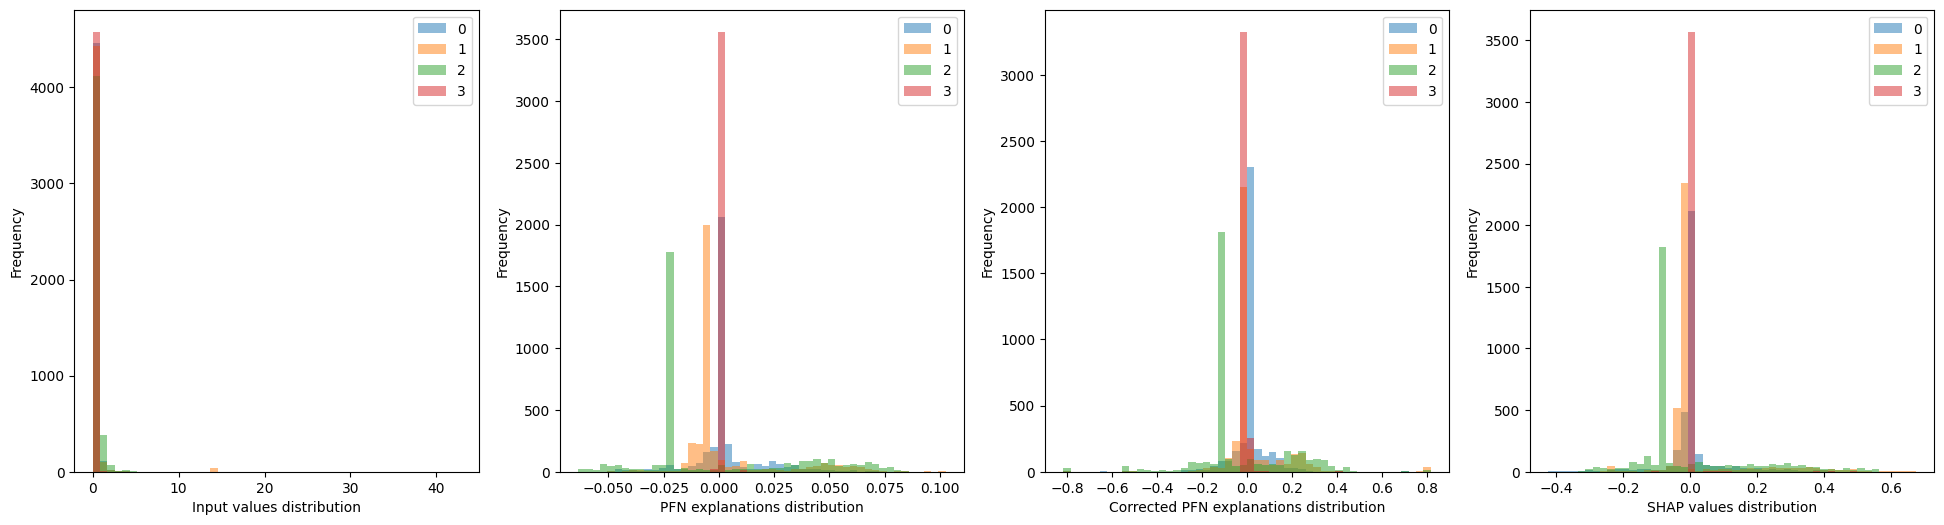

In [8]:
df_explanations = pd.DataFrame(explanations.astype(float), columns=df_train.columns.drop("target"))
df_explanations["target"] = y_test
df_explanations_corrected = pd.DataFrame(explanations_corrected.astype(float), columns=df_train.columns.drop("target"))
df_explanations_corrected["target"] = y_test
plot_explanations(df, df_explanations, df_explanations_corrected, df_shap)

# Check what the results would have looked like without training

In [ ]:
xai = ExplainerPFN(random_state=42)
xai.fit(X_train, y_train)
explanations = xai.predict(X_test.values, y_test)

In [ ]:
# Apply correction to ensure additivity (approach 2)
eps = (y_test - xai.base_value_) / explanations.sum(axis=1)
explanations_corrected = explanations * eps.reshape(-1, 1)

# This approach can lead to outliers, so we clip them
threshold = y_test.std() * 3
explanations_corrected = np.clip(explanations_corrected, a_min=-threshold, a_max=threshold)
explanations = np.clip(explanations, a_min=-threshold, a_max=threshold)

In [ ]:
analyze_correlation_results(df, df_shap, explanations, explanations_corrected, y_test, df_train)

,input_values_vs_target,shap_vs_target,pfn_exp_vs_target,pfn_exp_corr_vs_target,pfn_exp_vs_shap,pfn_exp_corr_vs_shap
0,0.126208,0.395394,0.967074,0.739499,0.413907,0.249437
1,-0.030224,0.675917,-0.026057,0.009389,-0.001045,0.014468
2,0.196988,0.831483,-0.237958,0.772208,-0.208786,0.613640
3,0.057371,0.085405,-0.252792,0.969979,-0.005471,0.094814
target,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


(<Figure size 2400x600 with 4 Axes>,
 array([<Axes: xlabel='Input values distribution', ylabel='Frequency'>,
        <Axes: xlabel='PFN explanations distribution', ylabel='Frequency'>,
        <Axes: xlabel='Corrected PFN explanations distribution', ylabel='Frequency'>,
        <Axes: xlabel='SHAP values distribution', ylabel='Frequency'>],
       dtype=object))

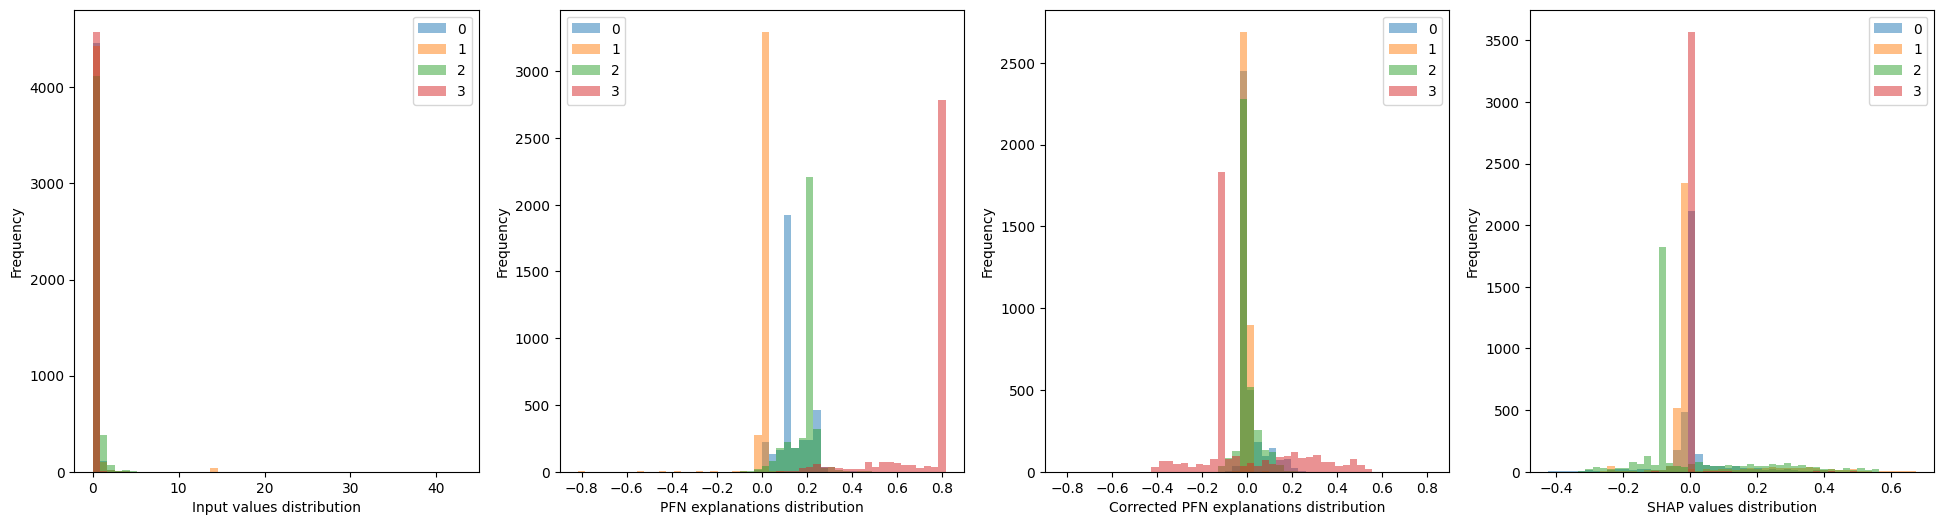

In [ ]:
df_explanations = pd.DataFrame(explanations.astype(float), columns=df_train.columns.drop("target"))
df_explanations["target"] = y_test
df_explanations_corrected = pd.DataFrame(explanations_corrected.astype(float), columns=df_train.columns.drop("target"))
df_explanations_corrected["target"] = y_test
plot_explanations(df, df_explanations, df_explanations_corrected, df_shap)